# Timeseries Minichallenge

Alessandro Mecchia, Paolo Nicolet
## Dataset:
Hotels

## Description
The dataset contains **7 years** of the **hotel demand and revenue** of 8 major tourist destinations in the US (e.g., Los Angeles, Orlando ...). The dataset contains sales, daily occupancy, demand, and revenue of the upper-middle class hotels. 

## Task:

Chose one city and produce **1-7 days ahead** forecast the Revenue column. **Use data between 2013 and 2020**





## 1. Data Loading and Initial Exploration

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime, timedelta

# Time series libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Scikit-learn for additional models
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Set style and suppress warnings
plt.style.use('default')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
with open('hotels.pk', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame if needed
if not isinstance(data, pd.DataFrame):
    df = pd.DataFrame(data)
else:
    df = data.copy()

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!
Dataset shape: (23254, 4)

Column names:
['Location', 'Revenue', 'Demand', 'Occupancy']


In [3]:
print(df.index.dtype)

datetime64[ns]


In [4]:
df.head()

,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,NewYork,2.442363e+06,13063.675000,81.991307
2013-01-02,NewYork,2.018559e+06,13069.608539,82.028548
2013-01-03,NewYork,1.927676e+06,13069.608539,82.028548
2013-01-04,NewYork,1.781664e+06,12653.271887,79.415502
2013-01-05,NewYork,1.824994e+06,12827.322364,80.507892


In [5]:
# Examine the data structure and basic info
print("Data Info:")
print(df.info())
print("\n" + "="*50)
print("Index (Date) Info:")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Number of days: {len(df.index.unique())}")
print("\n" + "="*50)
print("Unique locations:")
locations = df['Location'].unique()
print(locations)
print(f"Number of locations: {len(locations)}")
print("\n" + "="*50)
print("Data per location:")
print(df['Location'].value_counts().sort_values(ascending=False))

Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23254 entries, 2013-01-01 to 2020-10-31
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Location   23254 non-null  object 
 1   Revenue    23254 non-null  float64
 2   Demand     23254 non-null  float64
 3   Occupancy  23254 non-null  float64
dtypes: float64(3), object(1)
memory usage: 908.4+ KB
None

Index (Date) Info:
Date range: 2012-01-01 00:00:00 to 2020-10-31 00:00:00
Number of days: 3227

Unique locations:
['NewYork' 'Orlando' 'Chicago' 'LosAngeles' 'Washington' 'Atlanta'
 'Dallas' 'Boston']
Number of locations: 8

Data per location:
Location
Atlanta       3227
NewYork       2861
Chicago       2861
Orlando       2861
LosAngeles    2861
Washington    2861
Dallas        2861
Boston        2861
Name: count, dtype: int64


## 2. Data Preprocessing


In [6]:
# Basic statistics for each location
print("Revenue Statistics by Location:")
print("="*80)
revenue_stats = df.groupby('Location')['Revenue'].agg(['count', 'mean', 'std', 'min', 'max'])
revenue_stats['mean'] = revenue_stats['mean'].round(0)
revenue_stats['std'] = revenue_stats['std'].round(0)
print(revenue_stats)

print("\n\nMissing values check:")
print(df.isnull().sum())

print("\n\nData types:")
print(df.dtypes)

Revenue Statistics by Location:
            count       mean        std            min           max
Location                                                            
Atlanta      3227  1168859.0   407251.0  300130.994748  3.527372e+06
Boston       2861   815105.0   376528.0  114523.553351  2.035877e+06
Chicago      2861  1275021.0   532755.0  191560.618017  3.194662e+06
Dallas       2861   953418.0   313810.0  246828.548026  2.042266e+06
LosAngeles   2861  1047586.0   307256.0  164409.176800  1.839768e+06
NewYork      2861  3152937.0  1208497.0  588695.817812  7.940696e+06
Orlando      2861  1860535.0   691470.0   88994.827420  4.346277e+06
Washington   2861  1527573.0   597672.0  275723.044727  3.974323e+06


Missing values check:
Location     0
Revenue      0
Demand       0
Occupancy    0
dtype: int64


Data types:
Location      object
Revenue      float64
Demand       float64
Occupancy    float64
dtype: object


## 3. Exploratory Data Analysis and Visualization

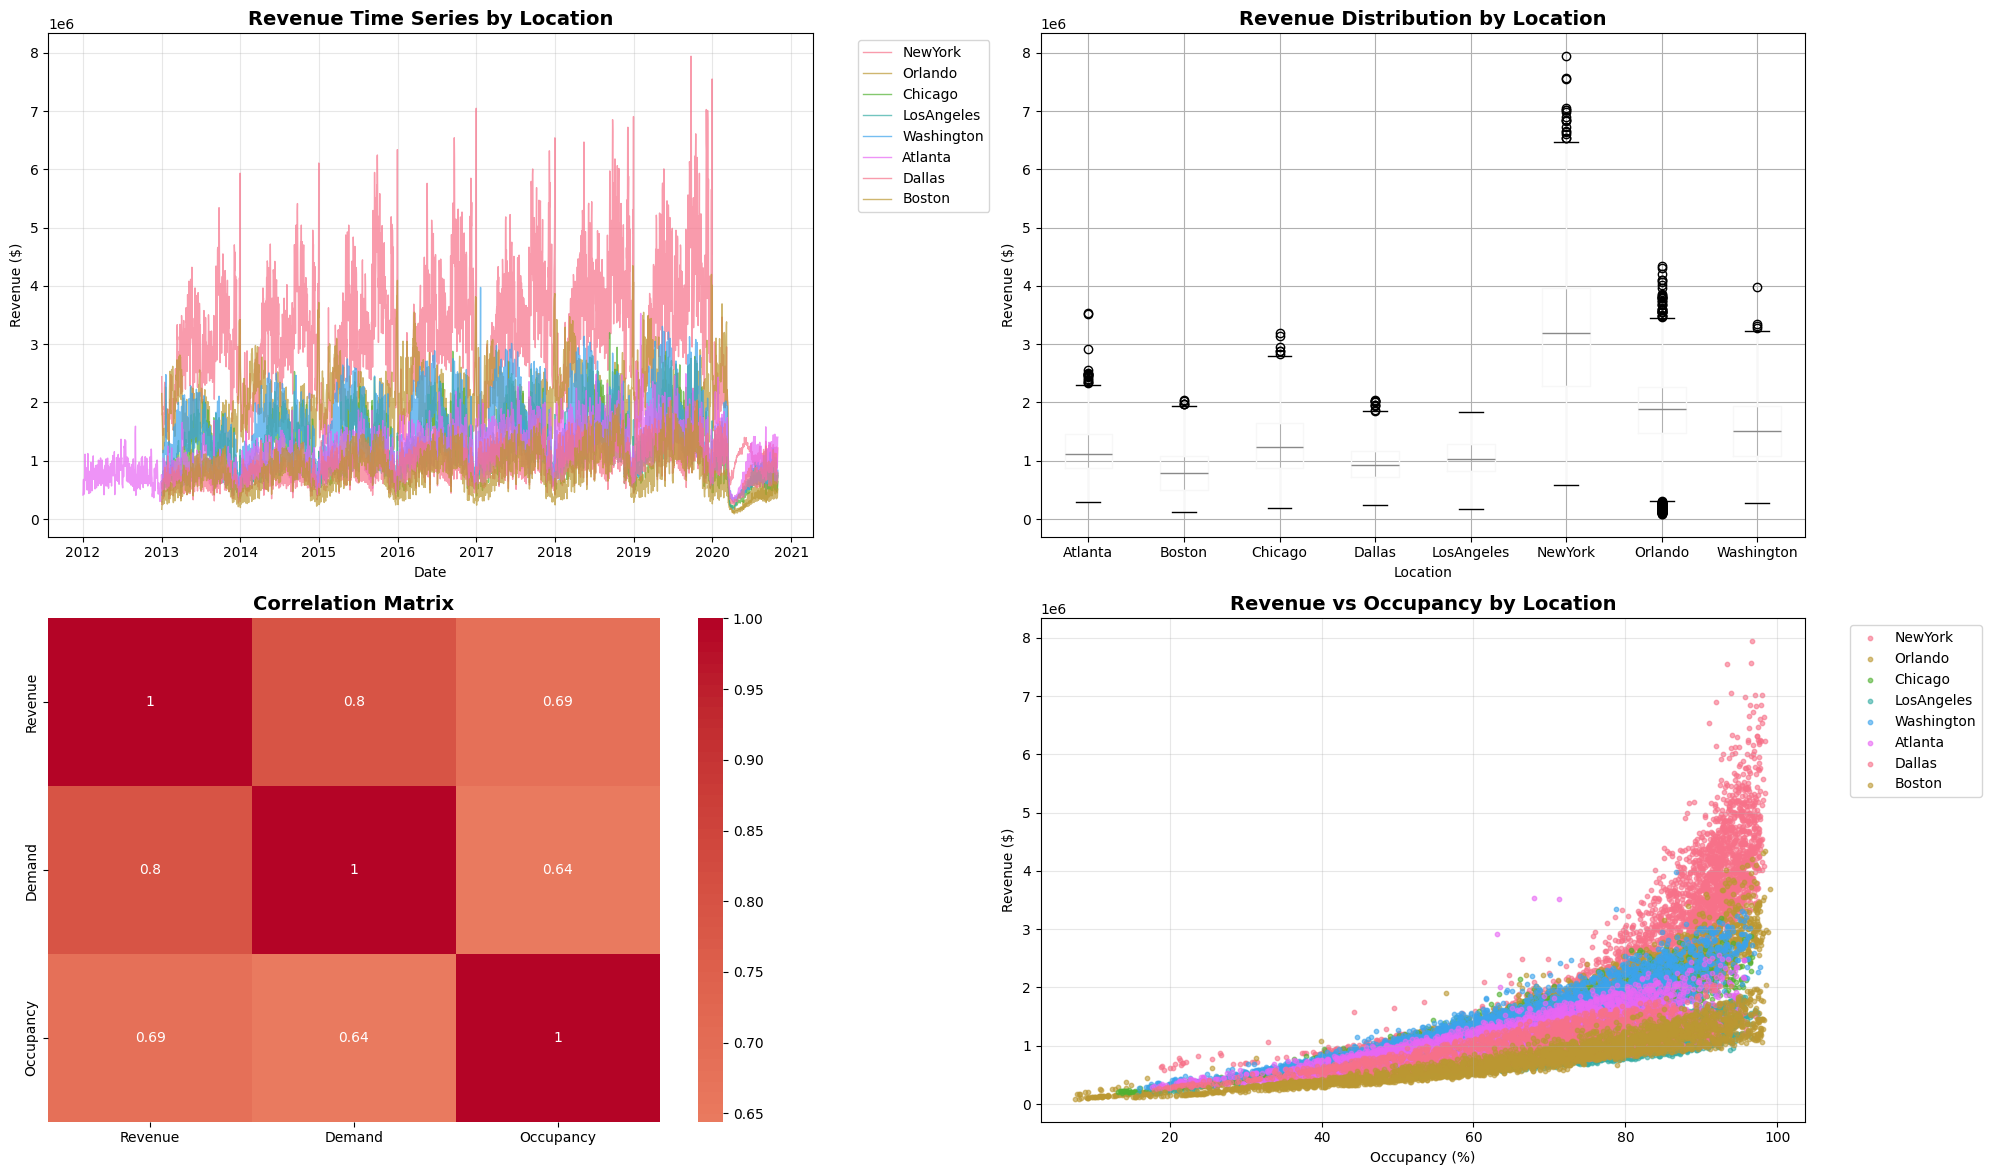

In [7]:
# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Revenue time series by location
ax1 = axes[0, 0]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax1.plot(location_data.index, location_data['Revenue'], 
             label=location, alpha=0.7, linewidth=1)
ax1.set_title('Revenue Time Series by Location', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Revenue ($)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Average revenue by location (box plot)
ax2 = axes[0, 1]
df.boxplot(column='Revenue', by='Location', ax=ax2)
ax2.set_title('Revenue Distribution by Location', fontsize=14, fontweight='bold')
ax2.set_xlabel('Location')
ax2.set_ylabel('Revenue ($)')
plt.suptitle('')  # Remove automatic title

# 3. Correlation matrix
ax3 = axes[1, 0]
# Select numeric columns for correlation
numeric_cols = ['Revenue', 'Demand', 'Occupancy']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 4. Revenue vs Occupancy scatter plot
ax4 = axes[1, 1]
for location in df['Location'].unique():
    location_data = df[df['Location'] == location]
    ax4.scatter(location_data['Occupancy'], location_data['Revenue'], 
                label=location, alpha=0.6, s=10)
ax4.set_title('Revenue vs Occupancy by Location', fontsize=14, fontweight='bold')
ax4.set_xlabel('Occupancy (%)')
ax4.set_ylabel('Revenue ($)')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

we can see an important correlation between Demand, Occupancy and our target Revenue. We want to check if there is collinearity between features to avoid overfitting in the model

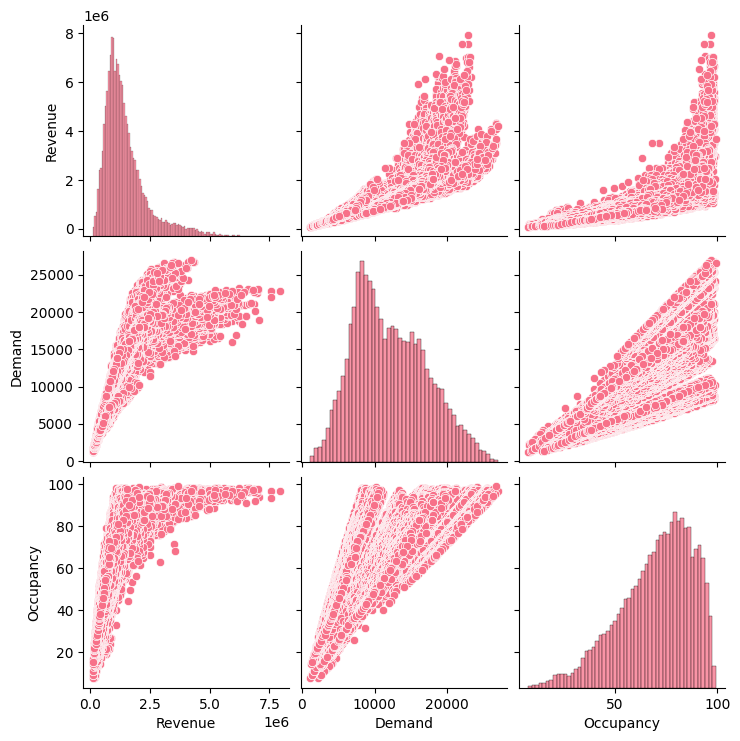

In [8]:
sns.pairplot(df[['Revenue', 'Demand', 'Occupancy']])
plt.show()

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Esempio: solo alcune feature
X = df[['Revenue', 'Demand', 'Occupancy']].dropna()

# Aggiungi una costante per il calcolo del VIF
from statsmodels.tools.tools import add_constant
X_const = add_constant(X)

vif = pd.DataFrame()
vif["feature"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif


,feature,VIF
0,const,20.075335
1,Revenue,3.173136
2,Demand,2.865540
3,Occupancy,1.990786


### Handling COVID
Because there is an external event that breaks the equilibrium condition, we decided to discard the COVID period, oterwise we can try to model it like a change of state (pre and post covid)

In [10]:
df = df.sort_index()
df = df.loc[:'2019-12-31']

## 4. City Selection and Focus

Based on the analysis, let's select **Boston** as our focus city for forecasting due to:
1. Highest revenue levels among all cities
2. Strong seasonal patterns visible in the time series
3. Good data quality and range

In [11]:
# Filter for one city
CITY = "Boston"
df_boston = df[df['Location'] == CITY].copy()

# Use index (already DateTimeIndex)
df_boston.index = pd.to_datetime(df_boston.index)

# Restrict date range
df_boston
df_boston.head()


,Location,Revenue,Demand,Occupancy
Date,,,,
2013-01-01,Boston,166542.843005,1896.791481,22.856617
2013-01-02,Boston,245252.313124,2744.958462,33.077154
2013-01-03,Boston,289687.425946,3172.063926,38.223838
2013-01-04,Boston,297390.047491,3308.052694,39.862523
2013-01-05,Boston,291848.455941,3235.525351,38.988557


In [12]:
print(df_boston.index.min(), "→", df_boston.index.max())

#verify that the intervals are regualr (daily) 

print(df_boston.index.to_series().diff().value_counts())

2013-01-01 00:00:00 → 2019-12-31 00:00:00
Date
1 days    2555
Name: count, dtype: int64


In [13]:
from ipywidgets import interact, interactive, IntSlider, DatePicker

start_picker = DatePicker(
    description='Start date',
    value=df.index.min().date(),
    disabled=False
)
end_picker = DatePicker(
    description='End date',
    value=df.index.max().date(),
    disabled=False
)

@interact(start=start_picker, end=end_picker)
def plot_time_series(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    plt.figure(figsize=(10, 4))
    plt.plot(df_boston.loc[mask].index, df_boston.loc[mask]['Revenue'], color='teal')
    plt.title(f"Hotel Revenue ({start} → {end})")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.grid(True, alpha=0.3)
    plt.show()


interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

because the line plot is a bit chaotic, let's analyse the timeserie in  a macro view

In [14]:
@interact(start=start_picker, end=end_picker)
def plot_rolling(start, end):
    mask = (df_boston.index >= pd.to_datetime(start)) & (df_boston.index <= pd.to_datetime(end))
    subset = df_boston.loc[mask]

    plt.figure(figsize=(12,6))
    plt.plot(subset['Revenue'].rolling(7, center=True).mean(), 
             label='Rolling 7-day', alpha=0.8, color='teal')
    plt.plot(subset['Revenue'].rolling(30, center=True).mean(), 
             label='Rolling 30-day (≈ monthly)', alpha=0.8, color='orange')
    plt.plot(subset['Revenue'].rolling(365, center=True).mean(), 
             label='Rolling 365-day (yearly)', alpha=0.9, color='crimson')

    plt.title(f'Hotel Revenue – Rolling Averages ({start} → {end})')
    plt.xlabel('Date')
    plt.ylabel('Revenue (smoothed)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(DatePicker(value=datetime.date(2012, 1, 1), description='Start date', step=1), DatePicke…

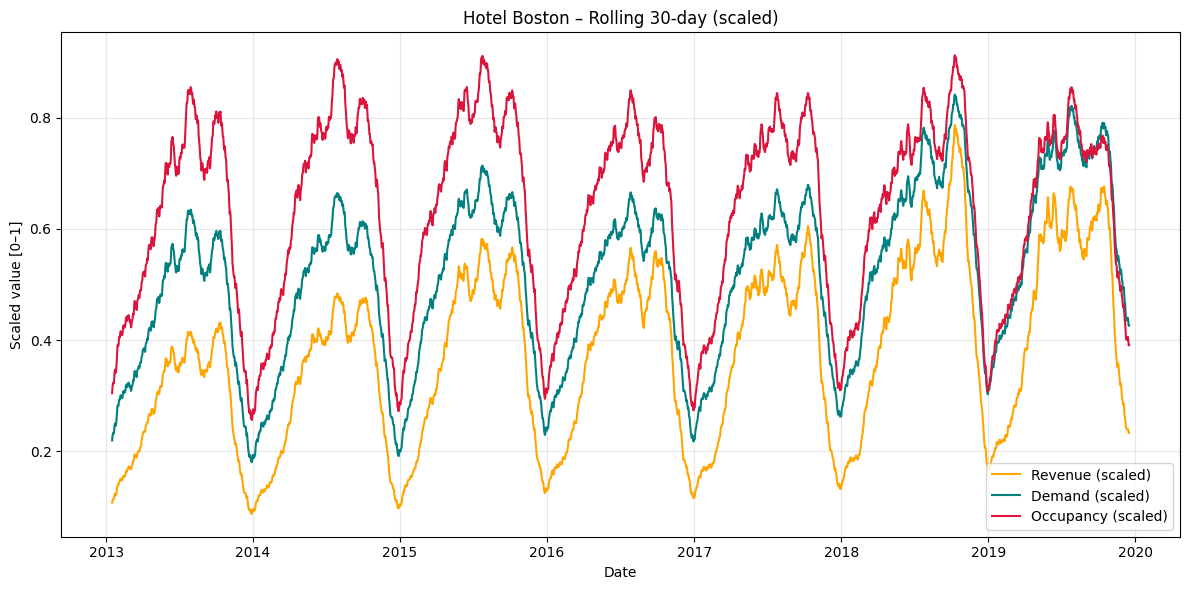

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_boston[['Revenue', 'Demand', 'Occupancy']])
scaled_df = pd.DataFrame(scaled, index=df_boston.index, columns=['Revenue', 'Demand', 'Occupancy'])

plt.figure(figsize=(12,6))
plt.plot(scaled_df['Revenue'].rolling(30, center=True).mean(), label='Revenue (scaled)', color='orange')
plt.plot(scaled_df['Demand'].rolling(30, center=True).mean(), label='Demand (scaled)', color='teal')
plt.plot(scaled_df['Occupancy'].rolling(30, center=True).mean(), label='Occupancy (scaled)', color='crimson')

plt.title('Hotel Boston – Rolling 30-day (scaled)')
plt.xlabel('Date')
plt.ylabel('Scaled value [0–1]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [16]:
@interact(metric=['Revenue', 'Demand', 'Occupancy'])
def plot_seasonal(metric):
    df_boston['Month'] = df_boston.index.month_name().str.slice(stop=3)
    df_boston['Year'] = df_boston.index.year
    monthly = df_boston.groupby(['Year', 'Month'])[metric].mean().reset_index()
    
    # Ordine corretto dei mesi
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly['Month'] = pd.Categorical(monthly['Month'], categories=month_order, ordered=True)
    
    plt.figure(figsize=(12,6))
    sns.lineplot(data=monthly, x='Month', y=metric, hue='Year', palette='coolwarm')
    plt.title(f'Seasonal Plot – Monthly {metric} by Year')
    plt.xlabel('Month')
    plt.ylabel(metric)
    plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

interactive(children=(Dropdown(description='metric', options=('Revenue', 'Demand', 'Occupancy'), value='Revenu…

Usually the revenues are higher in the warmer month

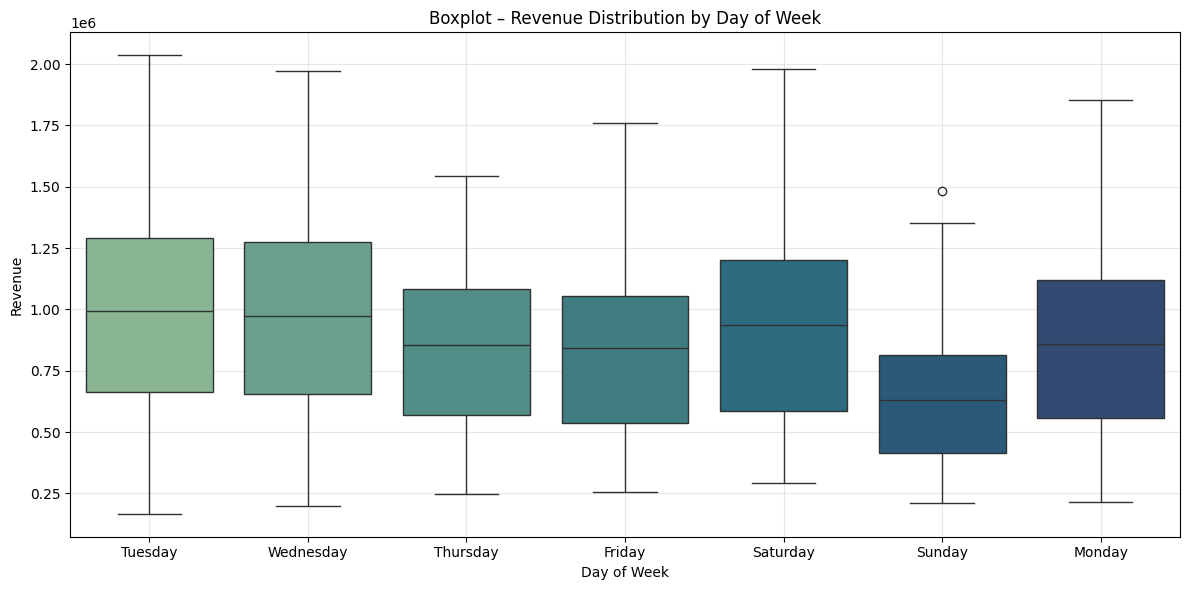

In [17]:
df_boston['DayOfWeek'] = df_boston.index.day_name()
plt.figure(figsize=(12,6))
sns.boxplot(data=df_boston, x='DayOfWeek', y='Revenue', palette='crest')
plt.title('Boxplot – Revenue Distribution by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

there is an assimetric seasionality also in the weeek, for this reason we will consider it in the decomposition

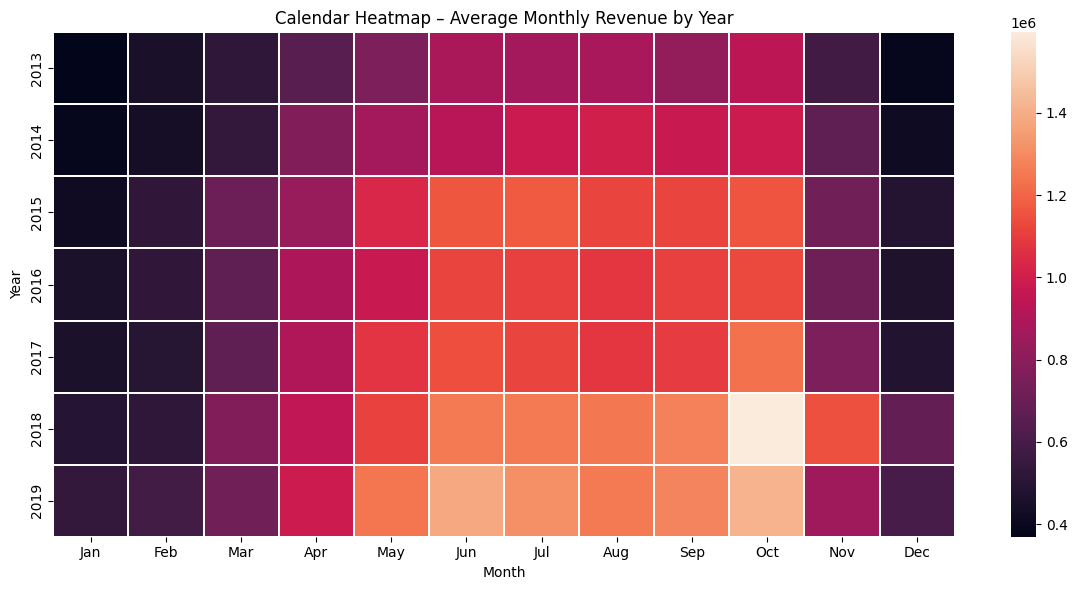

In [18]:
pivot2 = df_boston.pivot_table(values='Revenue',
                               index='Year',
                               columns='Month',
                               aggfunc='mean')
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot2 = pivot2[month_order]

plt.figure(figsize=(12,6))
sns.heatmap(pivot2, linewidths=0.3, annot=False)
plt.title('Calendar Heatmap – Average Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

The data shows very strong 12-month seasonality (peaking Jun-Oct) combined with a clear year-over-year growth trend

## 5. Decomposition

### Frequency Domain Analysis (FFT)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import ipywidgets as widgets
from ipywidgets import interact

# Funzione per calcolare e plottare la FFT
def plot_fft_interactive(column='Revenue', f_min=0.001, f_max=0.05, top_n=5):
    y = df_boston[column].dropna().values
    N = len(y)
    
    # Spaziatura temporale (giornaliera)
    time_diff = pd.Series(df_boston.index).diff().median().total_seconds()
    T = time_diff / (24 * 3600)
    
    # Calcolo FFT
    yf = fft(y)
    xf = fftfreq(N, T)[:N//2]
    magnitudes = 2.0/N * np.abs(yf[:N//2])
    
    # Filtro frequenze
    mask = (xf >= f_min) & (xf <= f_max)
    xf_filtered = xf[mask]
    magnitudes_filtered = magnitudes[mask]
    
    # Plot
    plt.figure(figsize=(10,5))
    plt.plot(xf_filtered, magnitudes_filtered, color='teal', lw=1.5)
    plt.xlabel('Frequency (1/day)')
    plt.ylabel('Magnitude')
    plt.title(f'FFT Spectrum – {column}')
    plt.grid(alpha=0.3)
    
    # Trova i top n picchi
    peaks_idx = np.argsort(magnitudes_filtered)[-top_n:]
    top_periods = []
    for idx in peaks_idx:
        freq = xf_filtered[idx]
        period = 1/freq
        plt.axvline(freq, color='orange', linestyle='--', alpha=0.7)
        plt.text(freq, magnitudes_filtered[idx], f'{period:.1f}d', fontsize=8, rotation=90, color='orange')
        top_periods.append(period)
    
    plt.show()
    
    # Output tabellare dei top periodi
    df_periods = pd.DataFrame({
        'Rank': range(1, len(top_periods)+1),
        'Period (days)': np.round(top_periods, 2)
    }).sort_values('Period (days)')
    display(df_periods)

# Interfaccia interattiva
interact(
    plot_fft_interactive,
    column=widgets.Dropdown(options=['Revenue', 'Demand', 'Occupancy'], value='Revenue', description='Feature:'),
    f_min=widgets.FloatSlider(value=0.001, min=0.0001, max=0.01, step=0.0001, description='Min freq:'),
    f_max=widgets.FloatSlider(value=0.05, min=0.001, max=0.2, step=0.001, description='Max freq:'),
    top_n=widgets.IntSlider(value=5, min=1, max=10, step=1, description='Top peaks:')
);


interactive(children=(Dropdown(description='Feature:', options=('Revenue', 'Demand', 'Occupancy'), value='Reve…

because we don't have missing values and we have high-frequency data (daily) that can exhibit multiple seasonal patterns we can use an extension of STL decomposition for mulitple seasonality known as **MSTL** using LOESS

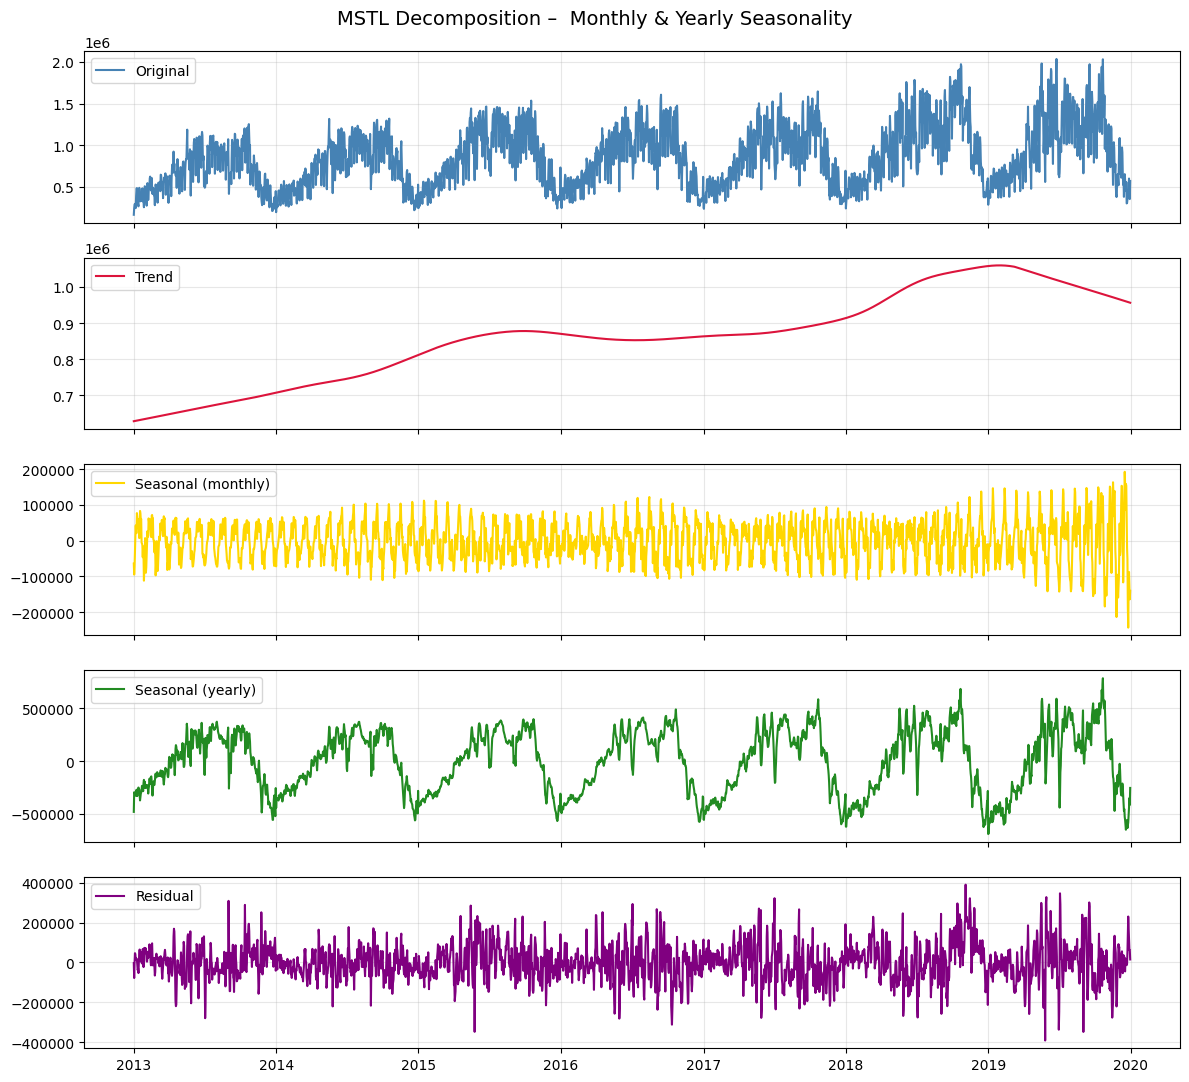

In [20]:
from statsmodels.tsa.seasonal import MSTL
y = df_boston['Revenue'].asfreq('D')
mstl = MSTL(y, periods=(7, 30, 365))
res = mstl.fit()

trend = res.trend
seasonal_month = res.seasonal['seasonal_30']
seasonal_year = res.seasonal['seasonal_365']
resid = res.resid

# Plot
fig, axs = plt.subplots(5, 1, figsize=(12, 11), sharex=True)
axs[0].plot(y, color='steelblue', label='Original')
axs[1].plot(trend, color='crimson', label='Trend')
axs[2].plot(seasonal_month, color='gold', label='Seasonal (monthly)')
axs[3].plot(seasonal_year, color='forestgreen', label='Seasonal (yearly)')
axs[4].plot(resid, color='purple', label='Residual')

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('MSTL Decomposition –  Monthly & Yearly Seasonality', fontsize=14)
plt.tight_layout()
plt.show()

Trend: Strong upward growth (~$650k → $1.1M) until 2019, then plateaus (pre-COVID signal).

Yearly Seasonality: Dominant pattern with ±$500k swings peaking Jun-Oct (summer tourism).

Monthly Seasonality: Rapid ±$100-200k fluctuations overlaid on yearly cycles.

### forecasting indicator - trend and seasonal strength

let's start with a first forecasting indicator, after the decomposition we expect that the timeseries has a strong trend and seasonality

In [21]:
trend_strength = max(0, 1 - np.var(res.resid) / np.var(res.trend + res.resid))
seasonal_strength = max(0, 1 - np.var(res.resid) / np.var(res.seasonal.sum(axis=1) + res.resid))

print(f"Trend strength: {trend_strength:.3f}")
print(f"Seasonality strength: {seasonal_strength:.3f}")

Trend strength: 0.638
Seasonality strength: 0.925


63.8% of the variance in the timeseries is given by the trend meaning that it is not completely stationary but shows a strong trend and 92.5% of the variance  is given by the seasonality, meaning that it's strong seasonal, near periodic. Models that use explicit seasonality will be very powerful

## 6. Stationarity Check (ADF)

In [22]:
def test_adf(series, title=""):
    result = adfuller(series.dropna())
    print(f"ADF test for {title}:")
    print("  Test statistic:", result[0])
    print("  p-value:", result[1])
    print("  # lags used:", result[2])
    print("  # observations:", result[3])
    for key, val in result[4].items():
        print(f"    critical {key}:", val)
    print()
    
test_adf(df_boston['Revenue'], title="Revenue")

ADF test for Revenue:
  Test statistic: -3.1230006322384054
  p-value: 0.024897204337802403
  # lags used: 27
  # observations: 2528
    critical 1%: -3.432939379929173
    critical 5%: -2.862683979868293
    critical 10%: -2.5673789838429837



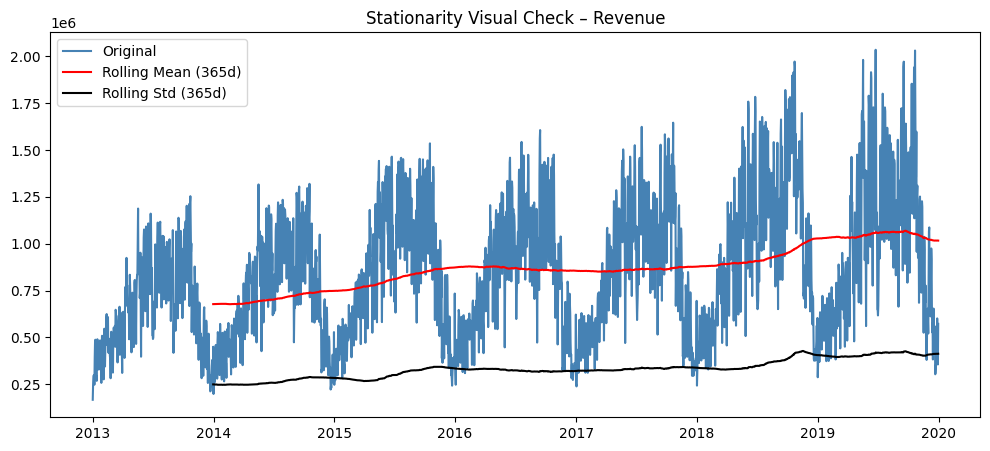

In [23]:
rolling_mean = y.rolling(window=365).mean()
rolling_std = y.rolling(window=365).std()

plt.figure(figsize=(12,5))
plt.plot(y, color='steelblue', label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (365d)')
plt.plot(rolling_std, color='black', label='Rolling Std (365d)')
plt.legend()
plt.title('Stationarity Visual Check – Revenue')
plt.show()

Visual inspection of the series shows a slow upward trend and strong seasonality, suggesting non-stationarity in the raw signal.
However, the ADF test rejects the null hypothesis of a unit root at the 5% significance level (p = 0.025), indicating that the series is weakly stationary.
This implies that the process does not exhibit stochastic drift but contains deterministic components (trend and seasonality) that can be modelled explicitly rather than removed through differencing.

## 7. Autocorrelation Analysis (ACF) and Partial Autocorrelation (PACF)

first we perform the ACF to see the timeseries correlation with itself at different lags

In [24]:
y_log = np.log(df_boston['Revenue'])

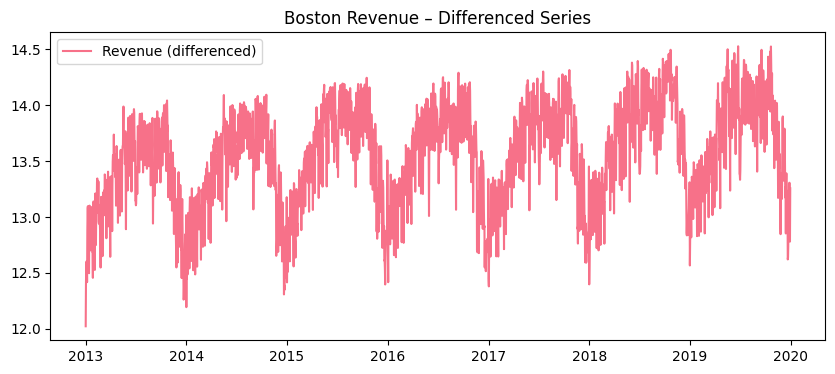

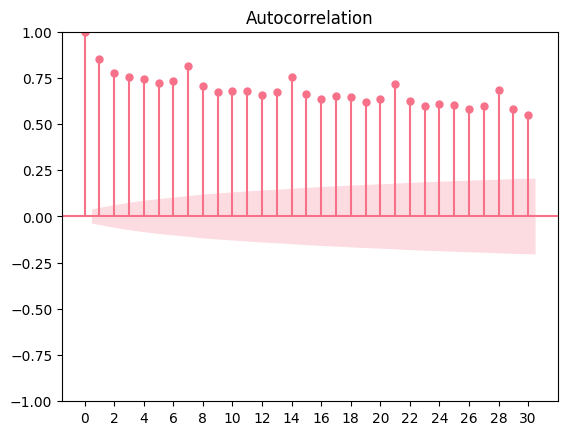

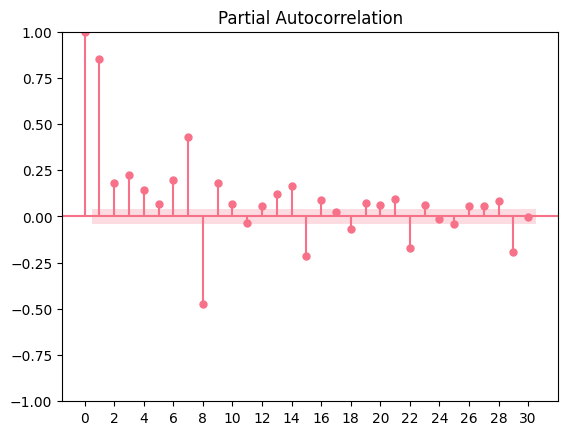

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))
plt.plot(y_log, label="Revenue (differenced)")
plt.title(f"{CITY} Revenue – Differenced Series")
plt.legend()
plt.show()

# ACF
plot_acf(y_log, lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()

# PACF
plot_pacf(y_log, lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()

**Differenced Series**

After log transformation and first differencing, the series oscillates around a constant mean (~13.5) with constant variance — achieving weak stationarity. The trend has been successfully removed.

**ACF (Autocorrelation Function)**

Slow exponential decay with significant positive lags up to ~20-30 days
Suggests strong persistence even after differencing
Pattern indicates potential MA(q) component needed in ARIMA
Seasonality still visible (regular spikes every ~7 lags = weekly pattern)

**PACF (Partial Autocorrelation)**

Lag 1: Very strong (~0.9) → dominant AR(1) component
Lag 7: Significant spike → confirms weekly seasonality
Lag ~14: Moderate spike → potential bi-weekly effect
Sharp cutoff after lag 1, then oscillates around zero → suggests AR(1) or low-order AR model

In [26]:
y_diff = y_log.diff().dropna()

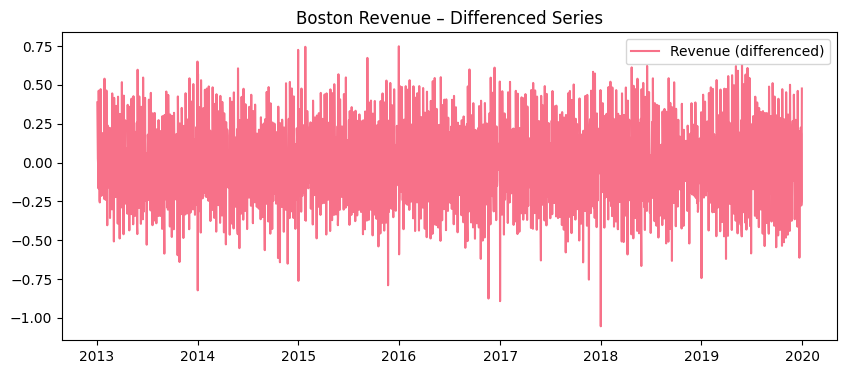

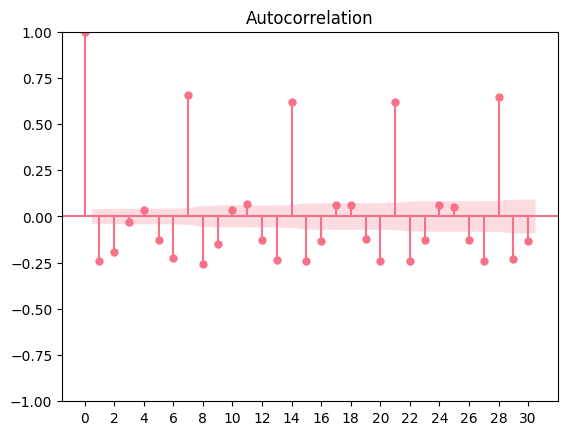

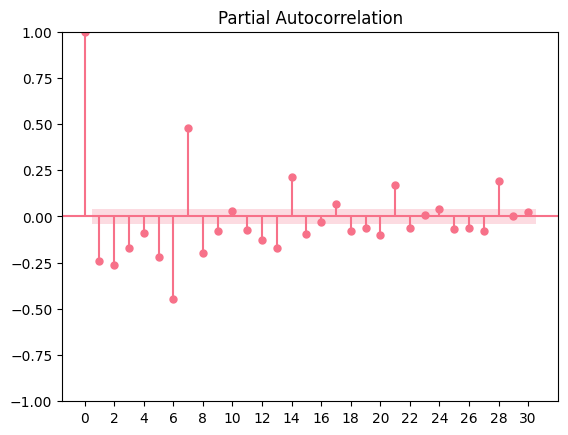

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,4))
plt.plot(y_diff, label="Revenue (differenced)")
plt.title(f"{CITY} Revenue – Differenced Series")
plt.legend()
plt.show()

# ACF
plot_acf(y_diff, lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()

# PACF
plot_pacf(y_diff, lags=30)
plt.xticks(ticks=np.arange(0, 31, 2))
plt.show()


After log transformation and first differencing, the series achieves weak stationarity with constant variance and no deterministic trend.
However, for forecasting purposes, the log-transformed level series (y_log) is preferred.
The ARIMA framework internally applies differencing as required (based on the optimal d and D parameters), allowing forecasts to be expressed on the same scale as the original log-revenue.

## 8. Outlier Detection

In [28]:
mstl = MSTL(y_log, periods=(7,30,365)).fit()
resid = pd.Series(mstl.resid, index=y_log.index)
resid_median = np.median(resid)
mad = np.median(np.abs(resid - resid_median))
z = (resid - resid_median) / (1.4826 * mad)
threshold = 3
outliers_high = z > threshold     
outliers_low  = z < -threshold     
outliers_all  = np.abs(z) > threshold

In [29]:
fitted_log = mstl.trend + mstl.seasonal.sum(axis=1)
fitted_revenue = np.exp(fitted_log)

# Serie Revenue originale (con stesso indice)
revenue = np.exp(y_log)

In [30]:
n_total = len(revenue)
n_outliers = outliers_all.sum()
print(f"Total outliers: {n_outliers} over {n_total} ({n_outliers/n_total:.2%})")

Total outliers: 43 over 2556 (1.68%)


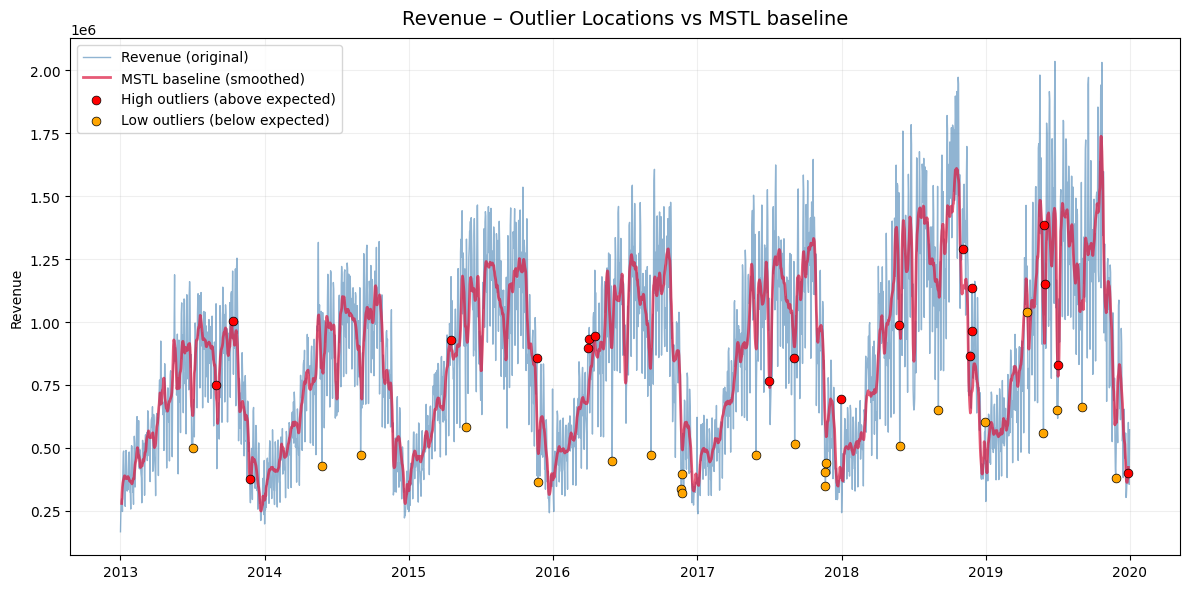

In [31]:

plt.figure(figsize=(12,6))
plt.plot(revenue, color='steelblue', linewidth=1, alpha=0.6, label='Revenue (original)')

# Baseline MSTL 
plt.plot(fitted_revenue.rolling(7, center=True).mean(),
         color='crimson', linewidth=2, alpha=0.7, label='MSTL baseline (smoothed)')
plt.scatter(revenue.index[outliers_high],
            revenue[outliers_high],
            color='red', s=40, edgecolor='black', linewidth=0.5,
            label='High outliers (above expected)', zorder=5)
plt.scatter(revenue.index[outliers_low],
            revenue[outliers_low],
            color='orange', s=40, edgecolor='black', linewidth=0.5,
            label='Low outliers (below expected)', zorder=5)

plt.title('Revenue – Outlier Locations vs MSTL baseline', fontsize=14, pad=10)
plt.ylabel('Revenue')
plt.legend(frameon=True, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Only 1.68% of points were flagged as outliers.
This level is consistent with natural business fluctuations and was therefore retained in the dataset, as these anomalies likely reflect real market events rather than noise.

## Benchmark Models
The naive, mean and seasonal will be our benchmarks for the development of more complex models.

In [32]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA, TBATS

In [33]:
y = df_boston['Revenue']

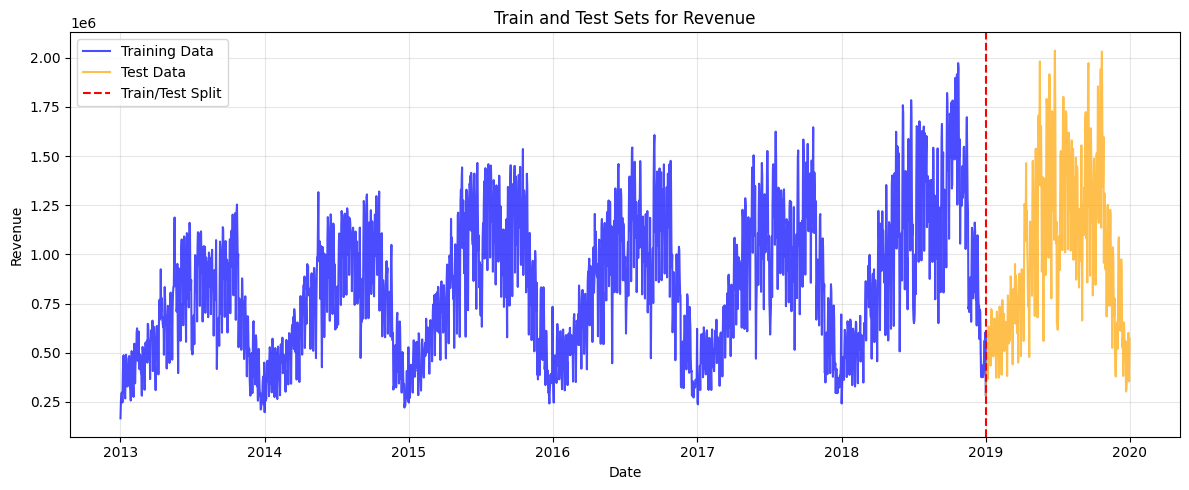

In [34]:
train = y.loc[:'2019-01-01']
test  = y.loc['2019-01-01':]

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Training Data', alpha=0.7, color='blue')
plt.plot(test.index, test, label='Test Data', alpha=0.7, color='orange')
plt.axvline(x=train.index[-1], color='red', linestyle='--', label='Train/Test Split')
plt.title('Train and Test Sets for Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
naive_forecast = pd.Series(train.iloc[-1], index=test.index)

naive_mae = np.mean(np.abs(test - naive_forecast))
naive_mse = np.mean((test - naive_forecast)**2)
naive_bias = np.mean(naive_forecast - test)

naive_in_sample = np.abs(np.diff(train))
naive_mase = naive_mae / np.mean(naive_in_sample)

print("Naïve Forecast Metrics:")
print(f"MAE:  {naive_mae:.4f}")
print(f"MSE:  {naive_mse:.4f}")
print(f"MASE: {naive_mase:.4f}")
print(f"BIAS: {naive_bias:.4f}")

Naïve log Forecast Metrics:
MAE:  729844.1904
MSE:  702220441127.1459
MASE: 4.9751
BIAS: -729844.1904


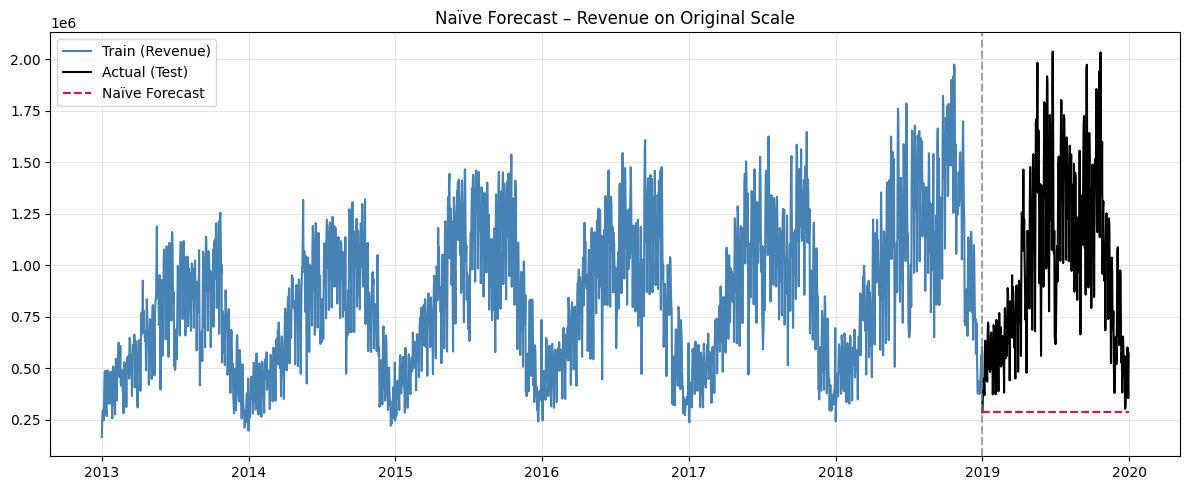

In [36]:

plt.figure(figsize=(12,5))
plt.plot(train, color='steelblue', label='Train (Revenue)')
plt.plot(test, color='black', label='Actual (Test)')
plt.plot(naive_forecast, color='crimson', linestyle='--', label='Naïve Forecast')

plt.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.7)
plt.title('Naïve Forecast – Revenue on Original Scale')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

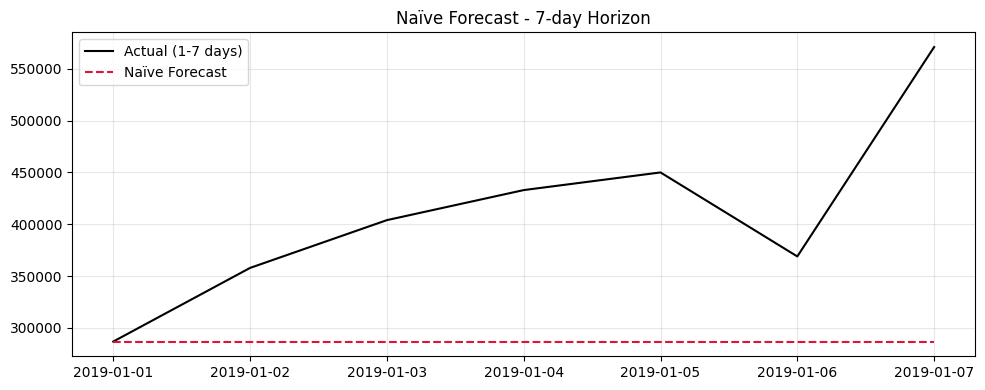

In [37]:
plt.figure(figsize=(10,4))
plt.plot(test[:7], label='Actual (1-7 days)', color='black')
plt.plot(naive_forecast[:7], label='Naïve Forecast', color='crimson', linestyle='--')
plt.title('Naïve Forecast - 7-day Horizon')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [40]:
train = pd.DataFrame({
    'unique_id': 'boston',
    'ds': train.index,   # le date
    'y': train.values    # i valori (log)
})

test = pd.DataFrame({
    'unique_id': 'boston',
    'ds': test.index,
    'y': test.values
})

In [41]:
season_length = 7  # stagionalità settimanale

models = [
    SeasonalNaive(season_length=season_length),
    AutoETS(season_length=season_length),        
    AutoARIMA(season_length=season_length)     
]

In [42]:
sf = StatsForecast(models=models, freq='D', n_jobs=-1)
sf = sf.fit(train)

In [43]:
h = len(test)
forecast_test = sf.predict(h=h)  

In [ ]:
fitted_values = sf.forecast(df=train, h=1, fitted=True)

In [ ]:
def evaluate_model(name, forecast_test, fitted_values, train, test):
    mask_forecast = forecast_test['unique_id'] == 'boston'
    y_pred = forecast_test.loc[mask_forecast, name].to_numpy().flatten()

    y_true = test['y'].to_numpy().flatten()

    mask_fit = fitted_values['unique_id'] == 'boston'
    y_fit = fitted_values.loc[mask_fit, name].to_numpy().flatten()

    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    bias = np.mean(y_pred - y_true)
    mase = mae / np.mean(np.abs(np.diff(train['y'].to_numpy().flatten())))


    print(f"\n{name} – Forecast Metrics")
    print(f"Real Scale: MAE={mae:,.2f} | MSE={mse:,.2f} | MASE={mase:.4f} | BIAS={bias:,.2f}")


    plt.figure(figsize=(13, 5))
    plt.plot(train['ds'], train['y'], color='steelblue', linewidth=1.2, label='Train (actual)')
    plt.plot(test['ds'], test['y'], color='black', linewidth=1.2, label='Test (actual)')
    # plt.plot(train['ds'], y_fit, '--', color='royalblue', linewidth=1.2, label='Fitted (in-sample)')
    plt.plot(test['ds'], y_pred, '--', color='crimson', linewidth=1.4, label=f'{name} Forecast (out-of-sample)')
    plt.axvline(x=test['ds'].iloc[0], color='gray', linestyle='--', alpha=0.7)
    plt.title(f'{name} – In-sample Fit & Out-of-sample Forecast', fontsize=13, pad=10)
    plt.xlabel('Date')
    plt.ylabel('Revenue (€)')
    plt.legend(frameon=True, loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4))
    plt.plot(test['ds'][:7], test['y'][:7], label='Actual (1–7 days)', color='black', linewidth=1.4)
    plt.plot(test['ds'][:7], y_pred[:7], '--', label=f'{name} Forecast', color='crimson', linewidth=1.4)
    plt.title(f'{name} – 7-Day Forecast Window', fontsize=13, pad=10)
    plt.xlabel('Date')
    plt.ylabel('Revenue')
    plt.legend(frameon=True, loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
for model_name in ['SeasonalNaive', 'AutoETS', 'AutoARIMA']:
    evaluate_model(model_name, forecast_test, fitted_values, train, test)